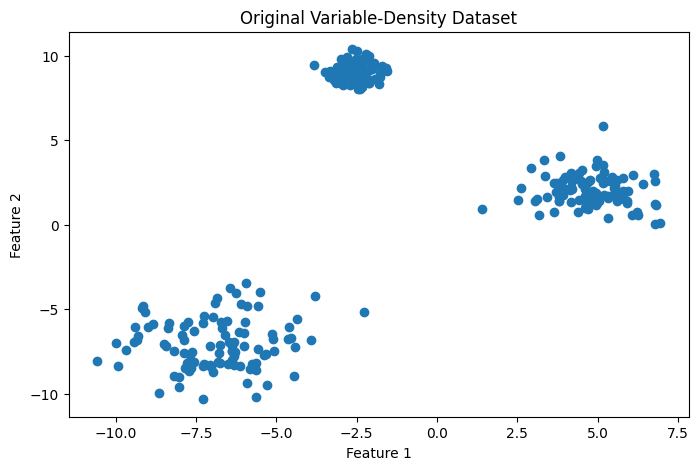

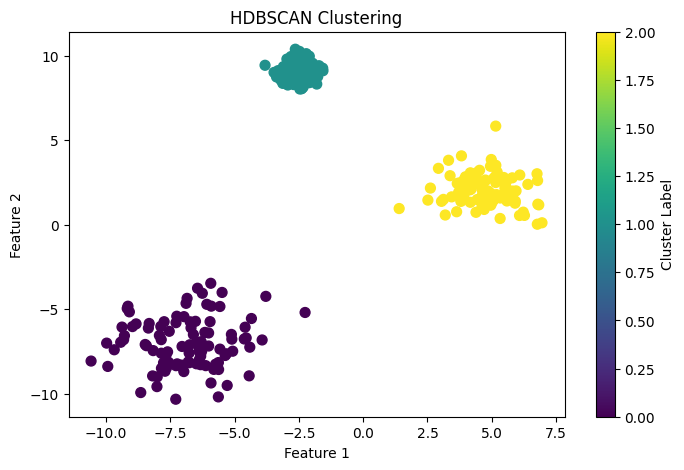

Evaluation Results
-------------------------
Number of Clusters: 3
Number of Noise Points: 0
Silhouette Score: 0.8540556688839549
Cluster 0: 100 data points
Cluster 1: 100 data points
Cluster 2: 100 data points

Membership Probabilities (First 10 Points):
[1.         0.77290823 0.55560419 0.73367772 0.26010575 1.
 1.         1.         0.87770349 0.87481083]


In [1]:
# ==========================================
# Experiment 6: HDBSCAN Clustering
# ==========================================

# 1. Import required libraries
import numpy as np
import matplotlib.pyplot as plt

import hdbscan

from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score


# 2. Generate variable-density dataset
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=[0.5, 1.0, 1.5],
    random_state=42
)


# 3. Visualize original dataset
plt.figure(figsize=(8, 5))

plt.scatter(X[:, 0], X[:, 1])

plt.title("Original Variable-Density Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


# ==========================================
# 4. Apply HDBSCAN
# ==========================================

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    metric='euclidean'
)

labels = clusterer.fit_predict(X)


# ==========================================
# 5. Visualize Clusters
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap='viridis',
    s=50
)

plt.title("HDBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Cluster Label")
plt.show()


# ==========================================
# 6. Evaluation
# ==========================================

# Exclude noise points
mask = labels != -1

# Count clusters excluding noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Count noise points
n_noise = np.sum(labels == -1)

print("Evaluation Results")
print("-------------------------")
print("Number of Clusters:", n_clusters)
print("Number of Noise Points:", n_noise)


# Calculate Silhouette Score
if n_clusters >= 2 and np.sum(mask) > n_clusters:

    score = silhouette_score(
        X[mask],
        labels[mask]
    )

    print("Silhouette Score:", score)

else:
    print("Silhouette Score: Not applicable")


# ==========================================
# 7. Display Cluster Information
# ==========================================

for i in sorted(set(labels)):

    if i == -1:
        print(f"Noise Points: {np.sum(labels == i)}")

    else:
        print(f"Cluster {i}: {np.sum(labels == i)} data points")


# ==========================================
# 8. Display Membership Probabilities
# ==========================================

print("\nMembership Probabilities (First 10 Points):")
print(clusterer.probabilities_[:10])